In [1]:
%load_ext cuml.accel
# %run /workspace/alvin/SAR_ML/notebooks/SSR/SSRtransforms_preloaded.py
%run /mnt/d/Users/Admin/Projects/dso/SAR_ML/notebooks/SSR/SSRtransforms_preloaded.py
import os
import random
from collections import defaultdict
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, ConcatDataset, Subset, Dataset
import re
import copy
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from tqdm import tqdm

In [2]:
def set_seed(seed=42):
    """Set all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # Uncomment only if you need 100% determinism and can handle errors
    # torch.use_deterministic_algorithms(True, warn_only=True)
    # os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
    
    os.environ["PYTHONHASHSEED"] = str(seed)

def worker_init_fn(worker_id):
    """DataLoader worker init for reproducibility"""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

In [3]:
# workspace = "/workspace/alvin/SAR_ML"
workspace = "/mnt/d/Users/Admin/Projects/dso/SAR_ML"
data_workspace = os.path.join(workspace, "data/SAMPLE")

In [4]:
gmm_cache = build_gmm_cache(input_dir = os.path.join(data_workspace, "mat_files/synth"), processing_func = LogMapping(c = 1000.0))

Found 1345 .mat files


Fitting GMMs: 100%|█████████████████████████████████████████████████████████████████| 1345/1345 [02:59<00:00,  7.48it/s]


In [5]:
synth_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/synth"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), SSRAugmentation(gmm_cache, alpha=0.6, beta=0.4, apply_prob=0.5, gaussian_noise = True, mu_s = 0.0, sigma_s = 0.3), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

meas_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

In [6]:
excluded_label = 7
excluded_label_name = synth_ds.classes[excluded_label]
print(f"Excluding label {excluded_label} ({excluded_label_name}) from synthetic dataset")
new_synth_ds = RemappedSubset(synth_ds, exclude_label=excluded_label)

Excluding label 7 (m60) from synthetic dataset


In [7]:
train_ds = new_synth_ds
test_ds = meas_ds

ds_dict = {"train" : train_ds, "test": test_ds}
dataset_sizes = {"train" : len(train_ds), "test": len(test_ds)}

In [8]:
seed_lst = [42]

label_lst = []
prob_lst = []
pred_lst = []

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
for i, seed in enumerate(seed_lst):
    print(f"Evaluating Run {i}: seed {seed}")
    new_model = models.resnet18(weights = None) # dont load ImageNet Weights
    new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(synth_ds.class_to_idx) - 1)
    )
    
    # Load your trained weights
    new_model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/OOD/rn18_seed{seed}_b16_rm_{excluded_label_name}.pth"),
        map_location=device
    ))
    
    new_model = new_model.to(device)
    new_model.eval()
    
    with torch.no_grad():
        for inputs, labels in DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=12, pin_memory=True, persistent_workers=True):
            inputs = inputs.to(device)
    
            outputs = new_model(inputs)
            probs = F.softmax(outputs, dim=1)
            confidence, preds = torch.max(probs, dim=1)
    
            prob_lst.append(confidence.cpu())
            pred_lst.append(preds.cpu())
            label_lst.append(labels)  # already on cpu from dataloader

confidences = torch.cat(prob_lst).numpy()
preds = torch.cat(pred_lst).numpy()
labels = torch.cat(label_lst).numpy()

inv_label_map = {v: k for k, v in new_synth_ds.label_map.items()}

preds_og = np.array([
    inv_label_map[p] for p in preds
])

Evaluating Run 0: seed 42


In [9]:
np.unique(labels, return_counts = True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 array([174, 107,  92, 129, 128, 129, 128, 176, 108, 174]))

In [10]:
np.unique(preds_og, return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 8, 9]),
 array([206, 111, 112, 153, 230,  94, 116, 192, 131]))

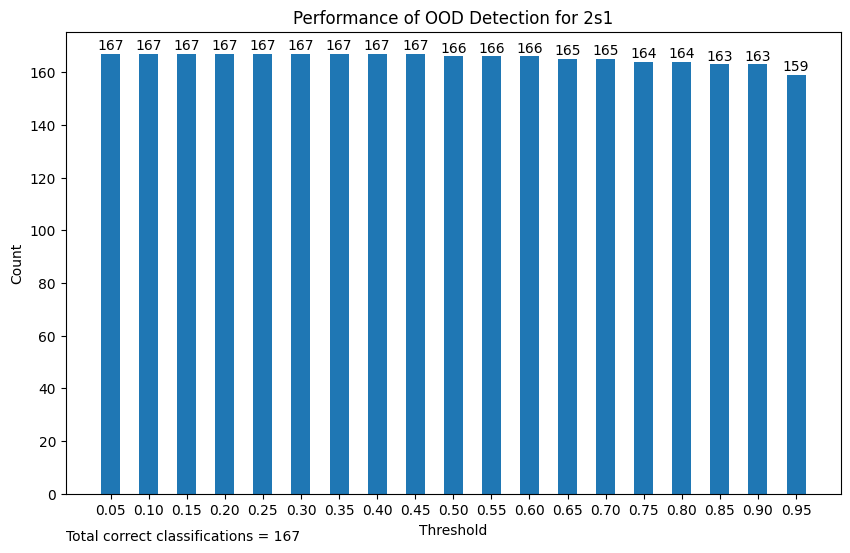

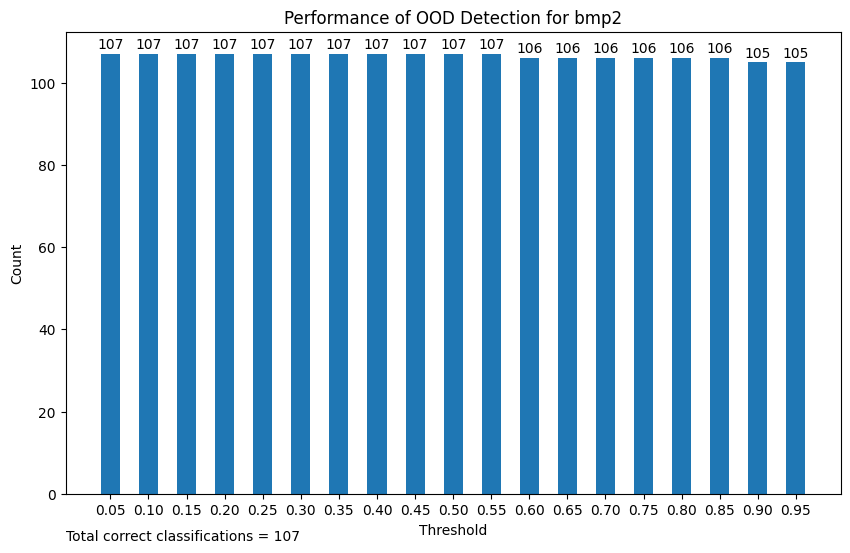

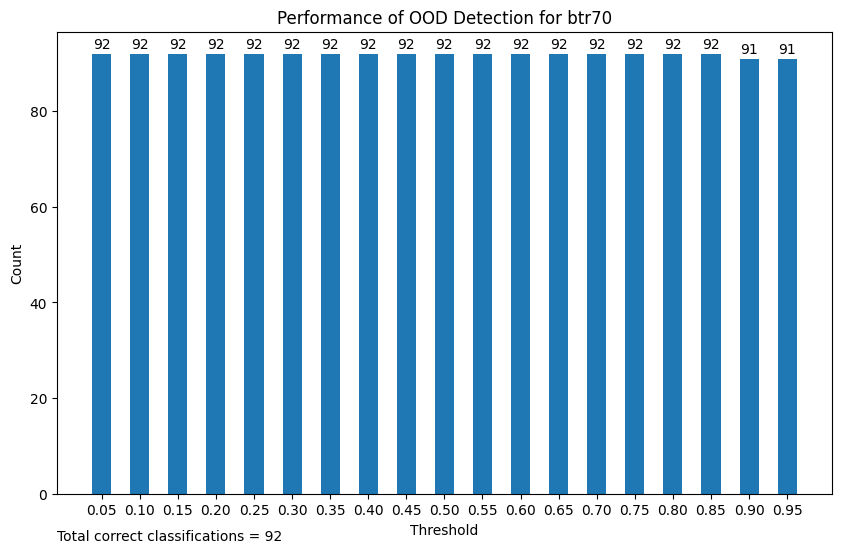

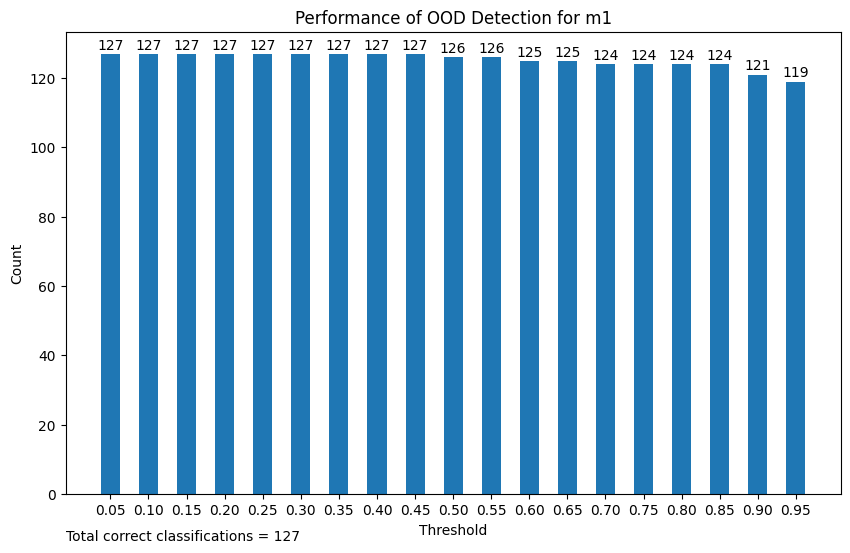

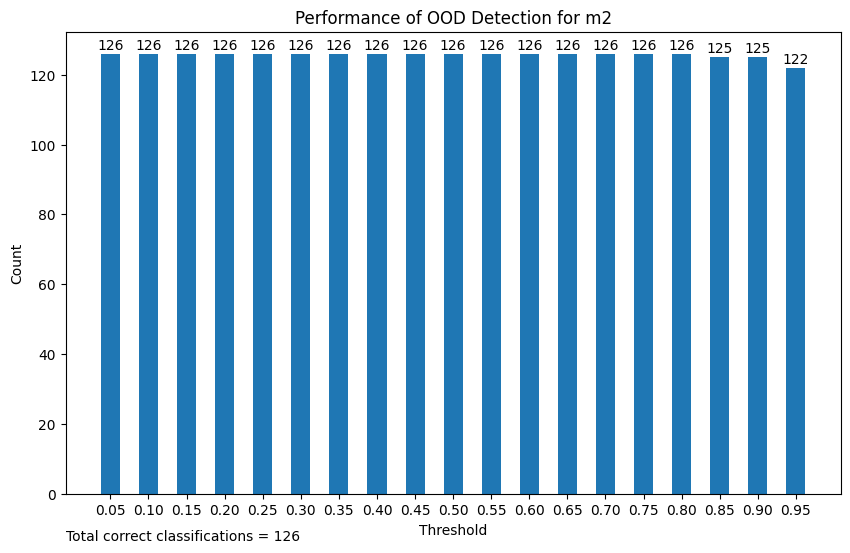

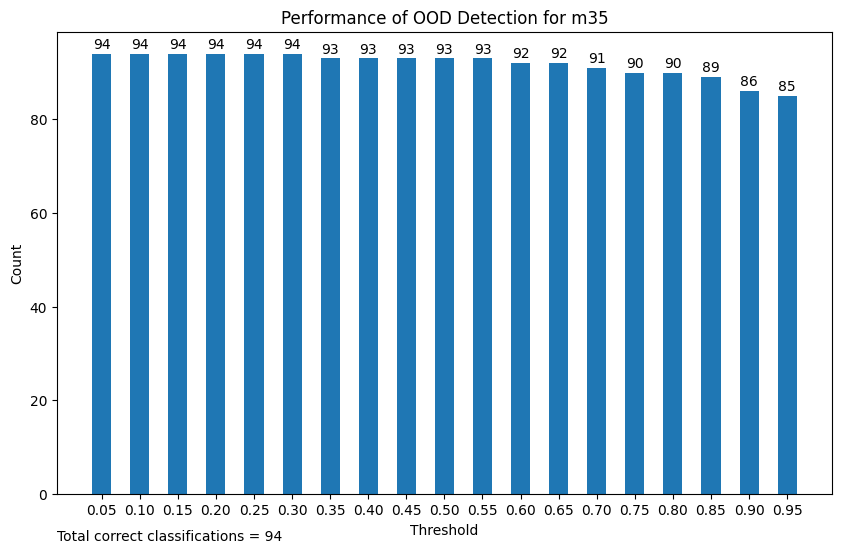

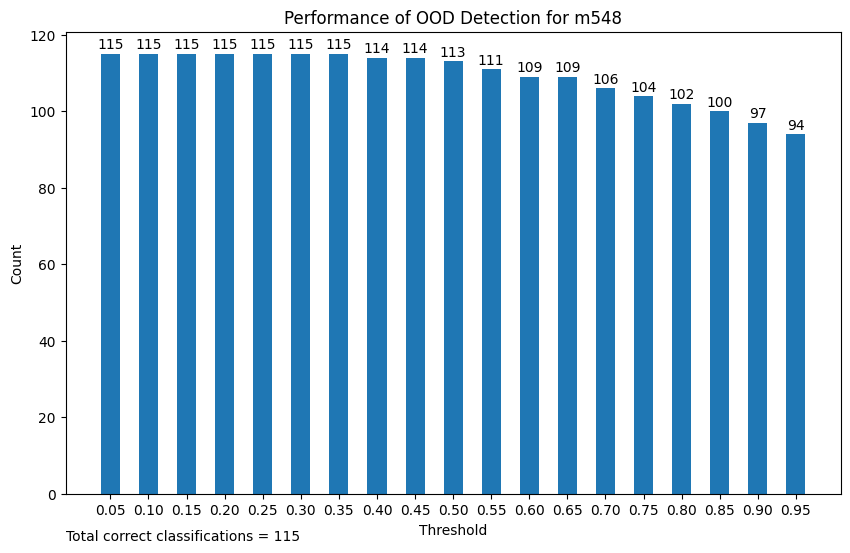

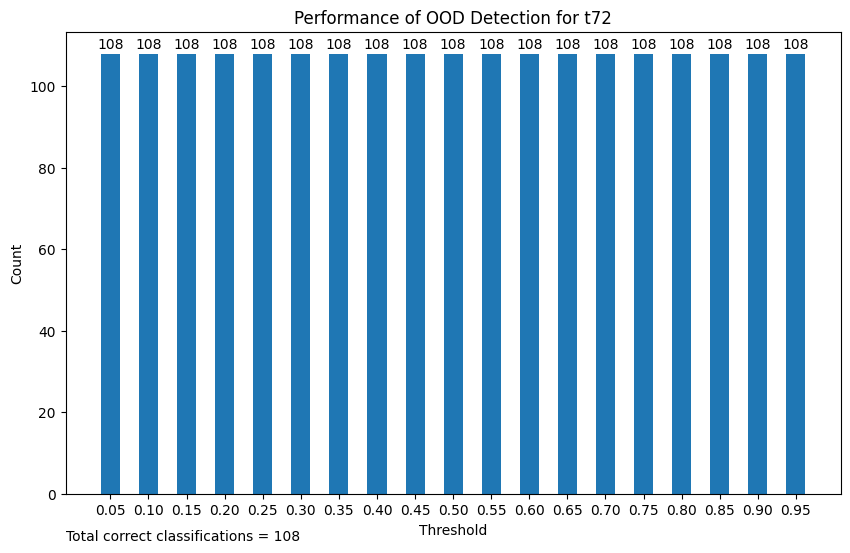

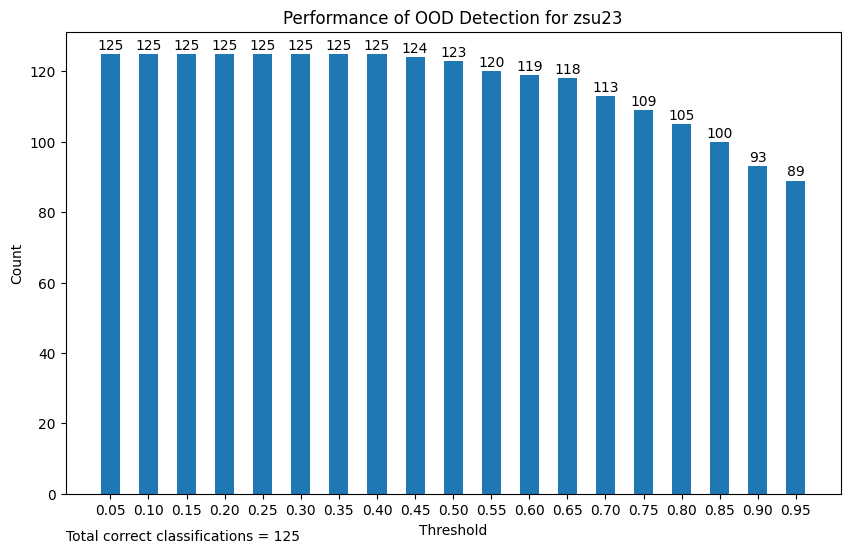

In [11]:
for j in list(inv_label_map.values()):
    class_label = j
    
    threshold = np.arange(0.05, 1.0, 0.05)
    count_above_threshold = []
    for t in threshold:
        correct_mask = ((labels == class_label) & (preds_og == class_label))
        correct_conf = confidences[correct_mask]
        count_above_threshold.append(np.sum(correct_conf >= t))
    count_above_threshold = np.array(count_above_threshold)

    fig = plt.figure(figsize=(10, 6))
    ax = fig.add_subplot(111)
    ax.bar(threshold, count_above_threshold, width=0.025, align='center')

    pltlocs, pltticks = plt.xticks()
    ax.set_xticks(threshold, [f"{t:.2f}" for t in threshold])

    for i, count in enumerate(count_above_threshold):
        ax.text(threshold[i], count + 0.5, str(count), ha='center', va='bottom')

    ax.text(0, -0.1, f"Total correct classifications = {correct_mask.sum()}", transform=ax.transAxes)

    ax.set_xlabel('Threshold')
    ax.set_ylabel('Count')
    ax.set_title(f'Performance of OOD Detection for {meas_ds.classes[j]}')
    plt.show()
